Import what you need

In [1]:
threads = 2

import os
os.environ['OMP_NUM_THREADS']=str(threads)
import tensorflow as tf

# PyTorch favours OMP_NUM_THREADS in environment
import torch

# Tensorflow needs explicit cofig calls
tf.config.threading.set_inter_op_parallelism_threads(threads)
tf.config.threading.set_intra_op_parallelism_threads(threads)

2025-11-03 20:47:34.612919: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-11-03 20:47:34.625906: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-11-03 20:47:34.638523: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-11-03 20:47:34.642557: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-11-03 20:47:34.653101: I tensorflow/core/platform/cpu_feature_guar

In [2]:
import mdtraj as md
import numpy as np
import matplotlib.pyplot as plt
import os
import shutil
import glob

* Batch_size = write the same batch_size you used as **hps['batch_size']** 

In [3]:
X_test = tf.data.Dataset.load('01.datasets/intcoords/test')

# get batched version of dataset to feed to AAE model for prediction
X_test_batched = X_test.batch(64,drop_remainder=True)

# get numpy version for testing purposes
X_test_np = np.stack(list(X_test))

test_geom = np.moveaxis(np.stack(list(tf.data.Dataset.load('01.datasets/geoms/test'))),2,0)
test_geom.shape

mol_model = torch.jit.load('./03.model/features.pt')
torch_encoder = torch.jit.load('./03.model/encoder-norm.pt')
torch_decoder = torch.jit.load('./03.model/decoder-norm.pt')

2025-11-03 20:47:36.665615: I tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2025-11-03 20:47:37.120995: I tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [4]:
conf = './../dataset_Thermal-unfolding/trpcage_npt400_nH.pdb'
tr_full = md.load('./../dataset_Thermal-unfolding/trpcage_ds_nH.xtc',top=conf)

m = torch.jit.load('./03.model/model.pt')
lows = m(torch.tensor(tr_full.xyz)).numpy()

lows.shape

(50001, 2)

In [10]:
base = md.load(conf)

rmsd = md.rmsd(tr_full,base[0])
rg = md.compute_rg(tr_full)

In [6]:
!pip install pandas

  Using cached pandas-2.3.3-cp310-cp310-manylinux_2_24_x86_64.manylinux_2_28_x86_64.whl (12.8 MB)
  Using cached tzdata-2025.2-py2.py3-none-any.whl (347 kB)


In [7]:
!pip install seaborn

  Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)



1. CORRELATION ANALYSIS

Axis z1:
  Pearson:  r= 0.796  p=0.00e+00
  Spearman: ρ= 0.773  p=0.00e+00
  Kendall:  τ= 0.567  p=0.00e+00

Axis z2:
  Pearson:  r= 0.357  p=0.00e+00
  Spearman: ρ= 0.305  p=0.00e+00
  Kendall:  τ= 0.204  p=0.00e+00

Partial correlations:
  r(z1,y|z2) = 0.820
  r(z2,y|z1) = 0.465

2. PREDICTIVE POWER (Block-CV) — FAST
Linear (2D):     R²=0.6920±0.0658  RMSE=0.5420±0.0363
Isotonic (1D):   R²=0.7745±0.0646  RMSE=0.4616±0.0488

3. MUTUAL INFORMATION — FAST
z1: MI=0.5917  baseline=0.0343  norm=0.9453
z2: MI=0.1673  baseline=0.0267  norm=0.8626

4. TEMPORAL ANALYSIS

Decorrel. times (1/e):
  z1: 877.0 ps
  z2: 147.0 ps
  y:  3761.0 ps

Integral corr. times:
  z1: 1876.9 ps
  z2: 787.8 ps
  y:  2934.2 ps

Optimal cross-correlation lag:
  z1-y: 0.0 ps
  z2-y: -20.0 ps

5. TICA (Time-lagged ICA)

Eigenvalues (λ), Implied times (ps), 1/e times (ps), Integral times (ps)
  tIC1: λ=0.6464  t_imp=229.2  tau_e=2882.0  tau_int=2403.5
  tIC2: λ=0.2931  t_imp=81.5  tau_e=67.0

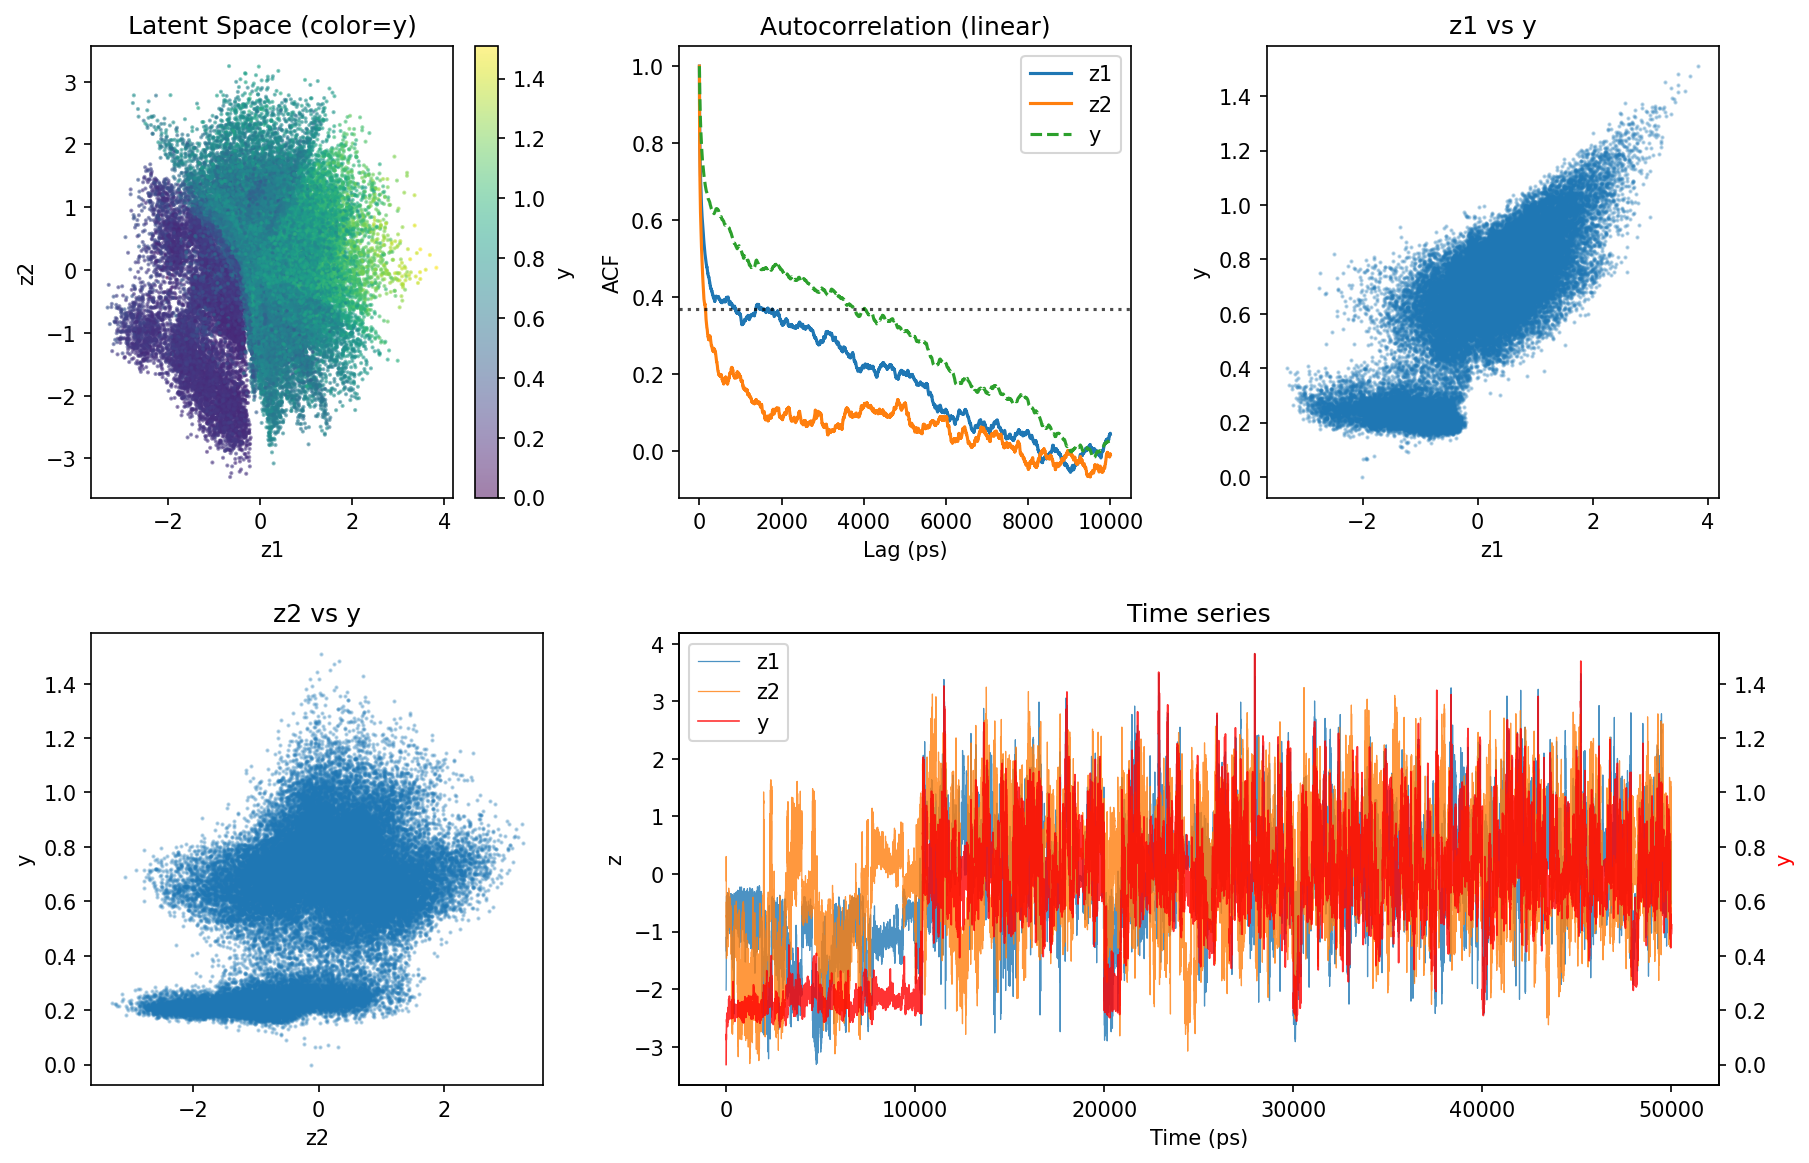


💡 Performance tips:
 - FAST_MODE=True (default) keeps 1 point every FAST_SUBSAMPLE_EVERY for MI/CV
 - Increase FAST_SUBSAMPLE_EVERY (e.g., 10) for more speed
 - Keep Kernel Ridge disabled unless needed
 - Choose block_size >= y decorrelation time (in frames) for conservative CV


In [8]:
#!/usr/bin/env python3
"""
Fast and robust latent-space analysis for MD trajectories (AAE)
- Axis-wise correlations (Pearson/Spearman/Kendall + partial)
- (Optional) Predictive power (Linear + Isotonic) with block-CV [FAST]
- (Optional) Mutual Information with block-shuffle baseline [FAST]
- Temporal analysis (ACF, 1/e decorrelation time, integral correlation time)
- TICA (time-lagged ICA): eigenproblem, implied times, projections, ACF of tICs

Fixed version with corrected TICA eigenvalue sorting and improved validations.
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats, signal, linalg
from sklearn.model_selection import GroupKFold
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.isotonic import IsotonicRegression
from sklearn.feature_selection import mutual_info_regression
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.decomposition import FastICA
import warnings
warnings.filterwarnings('ignore')

# ============================================================
# CONFIG
# ============================================================
CONFIG = {
    # --- Input ---
    'latent_path': "./../05.Test_disentanglment/lows.txt",   # txt/csv with >=2 columns (z1,z2); extra cols ignored
    'y_path': None,                 # if None, use an in-memory variable
    'column_sep': None,             # csv separator; None = auto (pandas)

    'use_existing_y': True,         # True: use an in-memory variable (e.g., 'rmsd' or 'rg')
    'y_var_name': "rmsd",

    # --- Time / CV ---
    'dt': 1.0,                      # ps per frame
    'block_size': 1000,             # frames per block (>= y decorrelation time recommended)
    'n_cv_splits': 5,

    # --- FAST mode (subsample heavy parts: CV & MI) ---
    'FAST_MODE': True,
    'FAST_SUBSAMPLE_EVERY': 5,      # keep 1 point every N for heavy steps

    # --- Mutual Information ---
    'DO_MI': True,
    'MI_N_NEIGHBORS': 5,

    # --- Predictive Power ---
    'DO_PREDICTIVE': True,
    'USE_RIDGE': False,             # Ridge vs Linear (same cost)
    'USE_KERNEL_RIDGE': False,      # disabled for speed; enable if needed
    'ISO_ON_1D_PROJ': True,         # Isotonic on best linear 1D projection

    # --- TICA ---
    'DO_TICA': True,
    'TICA_LAG_FRAMES': 100,         # lag in frames (choose based on physics & sampling)
    'TICA_EPS': 1e-6,               # ridge regularization for covariance
    'TICA_N_COMPONENTS': 2,         # up to latent dims

    # --- Plots ---
    'figsize': (14, 9),
    'dpi': 150,
    'save_plot_path': 'latent_analysis.png'
}

# ============================================================
# UTILS
# ============================================================
def load_data(path, column_sep=None):
    try:
        arr = pd.read_csv(path, sep=column_sep, engine="python",
                          comment="#", header=None).values
    except Exception:
        arr = np.loadtxt(path)
    return np.asarray(arr, dtype=float)

def ensure_valid(X):
    X = np.asarray(X, dtype=float)
    if X.ndim == 1:
        m = ~np.isfinite(X)
        if m.any():
            X[m] = np.nanmean(X[~m])
        return X
    for j in range(X.shape[1]):
        col = X[:, j]
        m = ~np.isfinite(col)
        if m.any():
            col[m] = np.nanmean(col[~m])
            X[:, j] = col
    return X

def make_blocks(n, size):
    return np.arange(n) // size

def maybe_subsample(arr, every):
    return arr if every <= 1 else arr[::every]

def residualize(X, T):
    lr = LinearRegression().fit(T, X)
    return X - lr.predict(T)

def block_shuffle_targets(y, blocks, rng):
    """Permute the order of blocks; preserves intra-block autocorrelation."""
    unique = np.unique(blocks)
    idx_blocks = [np.flatnonzero(blocks == u) for u in unique]
    perm = rng.permutation(len(idx_blocks))
    shuffled_idx = np.concatenate([idx_blocks[i] for i in perm])
    return y[shuffled_idx]

def acf_fft(x, max_lag):
    """Fast ACF via FFT (normalized)."""
    x = np.asarray(x, dtype=float)
    x = x - x.mean()
    n = len(x)
    # next power-of-two padding for efficiency
    nfft = 1 << (2 * n - 1).bit_length()
    fx = np.fft.rfft(x, nfft)
    c = np.fft.irfft(fx * np.conjugate(fx))[:n]
    c = c / (c[0] + 1e-12)
    return c[:max_lag]

def decorrelation_time_e(c, dt):
    """1/e decorrelation time: first lag where ACF drops below 1/e."""
    idx = np.where(c < 1/np.e)[0]
    return (idx[0] * dt) if len(idx) > 0 else np.nan

def integral_correlation_time(c, dt):
    """Integral correlation time: area under ACF (non-negative part)."""
    c_pos = np.maximum(c, 0.0)
    return np.trapz(c_pos, dx=dt)

# ============================================================
# TICA (FIXED: eigenvalue sorting by magnitude)
# ============================================================
def tica_fit(X, lag, eps=1e-6, n_components=None):
    """
    TICA on columns of X (time x dim). Returns eigenvalues (lambda),
    eigenvectors (columns of V), and the mean/whitening info.
    Solves: C_0t v = lambda C_00 v
    where C_00 = cov(X_t), C_0t = cov(X_t, X_{t+lag})
    
    FIXED: Eigenvalues sorted by magnitude (not just real part)
    """
    X = np.asarray(X, float)
    T, d = X.shape
    if lag <= 0 or lag >= T:
        raise ValueError("TICA_LAG_FRAMES must be in [1, T-1].")
    
    # Warning if lag is too large
    if lag > T // 2:
        warnings.warn(f"TICA lag ({lag}) is > half trajectory length ({T}). Results may be unstable.")
    
    if n_components is None:
        n_components = d

    # time-shifted blocks
    X0 = X[:-lag] - X[:-lag].mean(axis=0, keepdims=True)
    X1 = X[ lag:] - X[ lag:].mean(axis=0, keepdims=True)

    # covariances
    C00 = np.dot(X0.T, X0) / (len(X0) - 1)
    C0t = np.dot(X0.T, X1) / (len(X0) - 1)

    # regularize C00
    C00_reg = C00 + eps * np.eye(d)

    # solve generalized eigenproblem C0t v = lambda C00 v
    # convert to standard eigenproblem with whitening
    # C00 = E S E^T -> W = E S^{-1/2} -> \tilde{C} = W^T C0t W
    S, E = linalg.eigh(C00_reg)  # S ascending, E columns
    S = np.maximum(S, eps)
    Winv = E @ np.diag(np.sqrt(S)) @ E.T
    W = E @ np.diag(1.0/np.sqrt(S)) @ E.T

    C_tilde = W.T @ C0t @ W
    evals, evecs = linalg.eig(C_tilde)
    
    # FIXED: sort by magnitude (absolute value) descending
    idx = np.argsort(-np.abs(evals))
    evals = np.real(evals[idx])
    evecs = np.real(evecs[:, idx])

    # map back to original space
    V = W @ evecs  # columns are TICA directions in original space

    # keep only first n_components
    evals = evals[:n_components]
    V = V[:, :n_components]

    return evals, V, dict(W=W, Winv=Winv)

def tica_project(X, V):
    """Project time series X onto TICA components V."""
    return X @ V  # (T x d) @ (d x k) -> (T x k)

def implied_times(evals, lag_frames, dt_ps):
    """Implied times (ps): t_i = - lag*dt / ln(lambda_i), for 0<lambda<1."""
    ts = []
    for lam in evals:
        if 0 < lam < 1:
            ts.append(- (lag_frames * dt_ps) / np.log(lam))
        else:
            ts.append(np.nan)  # undefined or non-physical
    return np.array(ts)

# ============================================================
# ANALYZER
# ============================================================
class LatentSpaceAnalyzer:
    def __init__(self, Z, y, cfg):
        self.cfg = cfg
        self.Z_raw = ensure_valid(Z)
        self.y_raw = ensure_valid(y.reshape(-1))

        # Use first two columns only
        if self.Z_raw.ndim == 1 or self.Z_raw.shape[1] < 2:
            raise ValueError("Latent file must have at least 2 columns (z1, z2).")
        self.Z_raw = self.Z_raw[:, :2]

        # z-score normalization
        self.Z = (self.Z_raw - self.Z_raw.mean(0)) / self.Z_raw.std(0)
        self.y = (self.y_raw - self.y_raw.mean()) / (self.y_raw.std() + 1e-12)

        self.n = len(self.y)
        self.time = np.arange(self.n) * cfg['dt']
        self.blocks = make_blocks(self.n, cfg['block_size'])
        self.results = {}

    # ---------- 1) Correlations ----------
    def correlation_analysis(self):
        print("\n" + "="*60)
        print("1. CORRELATION ANALYSIS")
        print("="*60)
        res = {}
        for i in range(2):
            z = self.Z[:, i]
            r_p, p_p = stats.pearsonr(z, self.y)
            r_s, p_s = stats.spearmanr(z, self.y)
            r_k, p_k = stats.kendalltau(z, self.y)
            print(f"\nAxis z{i+1}:")
            print(f"  Pearson:  r={r_p:6.3f}  p={p_p:.2e}")
            print(f"  Spearman: ρ={r_s:6.3f}  p={p_s:.2e}")
            print(f"  Kendall:  τ={r_k:6.3f}  p={p_k:.2e}")
            res[f"z{i+1}"] = dict(pearson=(r_p,p_p), spearman=(r_s,p_s), kendall=(r_k,p_k))

        # partial correlations
        def _pcorr(idx_tgt, idx_ctrl):
            lr1 = LinearRegression().fit(self.Z[:, idx_ctrl:idx_ctrl+1], self.Z[:, idx_tgt])
            lr2 = LinearRegression().fit(self.Z[:, idx_ctrl:idx_ctrl+1], self.y)
            z_res = self.Z[:, idx_tgt] - lr1.predict(self.Z[:, idx_ctrl:idx_ctrl+1])
            y_res = self.y - lr2.predict(self.Z[:, idx_ctrl:idx_ctrl+1])
            return stats.pearsonr(z_res, y_res)[0]

        rz1 = _pcorr(0,1); rz2 = _pcorr(1,0)
        print(f"\nPartial correlations:")
        print(f"  r(z1,y|z2) = {rz1:.3f}")
        print(f"  r(z2,y|z1) = {rz2:.3f}")
        self.results['correlations'] = res

    # ---------- 2) Predictive Power (FAST) ----------
    def predictive_power(self):
        if not self.cfg['DO_PREDICTIVE']:
            return
        print("\n" + "="*60)
        print("2. PREDICTIVE POWER (Block-CV) — FAST")
        print("="*60)

        every = self.cfg['FAST_SUBSAMPLE_EVERY'] if self.cfg['FAST_MODE'] else 1
        Z = maybe_subsample(self.Z, every)
        y = maybe_subsample(self.y, every)
        blocks = make_blocks(len(y), max(1, self.cfg['block_size']//every))
        
        # IMPROVED: Validation for effective block size
        effective_block_size = max(1, self.cfg['block_size'] // every)
        if effective_block_size < 10:
            warnings.warn(f"Effective block size ({effective_block_size}) < 10. CV may be unreliable.")

        gkf = GroupKFold(n_splits=self.cfg['n_cv_splits'])
        ModelLR = Ridge(alpha=1.0) if self.cfg['USE_RIDGE'] else LinearRegression()

        def eval_model(X, y, blocks, model, proj_is_1d=False):
            r2s, rmses = [], []
            for tr, te in gkf.split(X, y, groups=blocks):
                if proj_is_1d:
                    model.fit(X[tr].ravel(), y[tr])
                    y_hat = model.transform(X[te].ravel())
                else:
                    model.fit(X[tr], y[tr])
                    y_hat = model.predict(X[te])
                r2s.append(r2_score(y[te], y_hat))
                rmses.append(np.sqrt(mean_squared_error(y[te], y_hat)))
            return np.mean(r2s), np.std(r2s), np.mean(rmses), np.std(rmses)

        # Linear 2D
        r2m, r2s, rm, rs = eval_model(Z, y, blocks, ModelLR)
        print(f"Linear (2D):     R²={r2m:.4f}±{r2s:.4f}  RMSE={rm:.4f}±{rs:.4f}")

        # Isotonic on best linear projection
        if self.cfg['ISO_ON_1D_PROJ']:
            lr_full = LinearRegression().fit(Z, y)
            proj = (Z @ lr_full.coef_).reshape(-1,1)
            iso = IsotonicRegression(out_of_bounds='clip')
            r2m, r2s, rm, rs = eval_model(proj, y, blocks, iso, proj_is_1d=True)
            print(f"Isotonic (1D):   R²={r2m:.4f}±{r2s:.4f}  RMSE={rm:.4f}±{rs:.4f}")

        # Kernel Ridge — disabled for speed (enable if needed)
        if self.cfg['USE_KERNEL_RIDGE']:
            from sklearn.kernel_ridge import KernelRidge
            krr = KernelRidge(alpha=1e-2, kernel='rbf', gamma=0.5)
            r2m, r2s, rm, rs = eval_model(Z, y, blocks, krr)
            print(f"Kernel RBF (2D): R²={r2m:.4f}±{r2s:.4f}  RMSE={rm:.4f}±{rs:.4f}")

    # ---------- 3) Mutual Information (FAST) ----------
    def mutual_information(self):
        if not self.cfg['DO_MI']:
            return
        print("\n" + "="*60)
        print("3. MUTUAL INFORMATION — FAST")
        print("="*60)

        every = self.cfg['FAST_SUBSAMPLE_EVERY'] if self.cfg['FAST_MODE'] else 1
        Z = maybe_subsample(self.Z, every)
        y = maybe_subsample(self.y, every)
        blocks = make_blocks(len(y), max(1, self.cfg['block_size']//every))

        mi = mutual_info_regression(Z, y, n_neighbors=self.cfg['MI_N_NEIGHBORS'], random_state=0)
        rng = np.random.default_rng(0)
        y_perm = block_shuffle_targets(y, blocks, rng)
        mi_base = mutual_info_regression(Z, y_perm, n_neighbors=self.cfg['MI_N_NEIGHBORS'], random_state=0)
        mi_norm = mi / (mi + mi_base + 1e-12)

        for i in range(2):
            print(f"z{i+1}: MI={mi[i]:.4f}  baseline={mi_base[i]:.4f}  norm={mi_norm[i]:.4f}")

        self.results['mi'] = {'raw': mi, 'baseline': mi_base, 'normalized': mi_norm}

    # ---------- 4) Temporal Analysis ----------
    def temporal_analysis(self):
        print("\n" + "="*60)
        print("4. TEMPORAL ANALYSIS")
        print("="*60)
        max_lag = min(10000, self.n//4)  # more room for long tails

        acf_z1 = acf_fft(self.Z[:,0], max_lag)
        acf_z2 = acf_fft(self.Z[:,1], max_lag)
        acf_y  = acf_fft(self.y,      max_lag)

        tz1 = decorrelation_time_e(acf_z1, self.cfg['dt'])
        tz2 = decorrelation_time_e(acf_z2, self.cfg['dt'])
        ty  = decorrelation_time_e(acf_y,  self.cfg['dt'])

        it_z1 = integral_correlation_time(acf_z1, self.cfg['dt'])
        it_z2 = integral_correlation_time(acf_z2, self.cfg['dt'])
        it_y  = integral_correlation_time(acf_y,  self.cfg['dt'])

        print("\nDecorrel. times (1/e):")
        print(f"  z1: {tz1:.1f} ps")
        print(f"  z2: {tz2:.1f} ps")
        print(f"  y:  {ty:.1f} ps")
        print("\nIntegral corr. times:")
        print(f"  z1: {it_z1:.1f} ps")
        print(f"  z2: {it_z2:.1f} ps")
        print(f"  y:  {it_y:.1f} ps")

        # cross-correlation lags
        def ccf(x,y,L):
            cc = signal.correlate(x - x.mean(), y - y.mean(), mode='full')
            cc /= (x.std() * y.std() * len(x))
            center = len(cc)//2
            return cc[center-L:center+L+1]

        cc1 = ccf(self.Z[:,0], self.y, max_lag)
        cc2 = ccf(self.Z[:,1], self.y, max_lag)
        lags = np.arange(-max_lag, max_lag+1) * self.cfg['dt']
        lag1 = lags[np.argmax(np.abs(cc1))]
        lag2 = lags[np.argmax(np.abs(cc2))]
        print("\nOptimal cross-correlation lag:")
        print(f"  z1-y: {lag1:.1f} ps")
        print(f"  z2-y: {lag2:.1f} ps")

        self.results['temporal'] = {
            'acf_z1':acf_z1, 'acf_z2':acf_z2, 'acf_y':acf_y,
            'decorr_times':(tz1,tz2,ty),
            'integral_times':(it_z1,it_z2,it_y),
            'ccf_z1y':cc1, 'ccf_z2y':cc2, 'lags':(lag1,lag2)
        }

    # ---------- 5) TICA ----------
    def tica_analysis(self):
        if not self.cfg['DO_TICA']:
            return
        print("\n" + "="*60)
        print("5. TICA (Time-lagged ICA)")
        print("="*60)
        lag = self.cfg['TICA_LAG_FRAMES']
        eps = self.cfg['TICA_EPS']
        k   = min(self.cfg['TICA_N_COMPONENTS'], self.Z.shape[1])

        evals, V, info = tica_fit(self.Z, lag=lag, eps=eps, n_components=k)
        Z_tic = tica_project(self.Z, V)
        t_impl = implied_times(evals, lag, self.cfg['dt'])

        # ACF for each tIC
        max_lag = min(10000, self.n//4)
        acfs = [acf_fft(Z_tic[:,i], max_lag) for i in range(Z_tic.shape[1])]
        tau_e = [decorrelation_time_e(acfs[i], self.cfg['dt']) for i in range(Z_tic.shape[1])]
        tau_int = [integral_correlation_time(acfs[i], self.cfg['dt']) for i in range(Z_tic.shape[1])]

        print("\nEigenvalues (λ), Implied times (ps), 1/e times (ps), Integral times (ps)")
        for i, lam in enumerate(evals):
            print(f"  tIC{i+1}: λ={lam:.4f}  t_imp={t_impl[i]:.1f}  tau_e={tau_e[i]:.1f}  tau_int={tau_int[i]:.1f}")

        self.results['tica'] = {
            'evals': evals, 'V': V, 'Z_tic': Z_tic,
            'implied_times': t_impl,
            'acfs': acfs, 'tau_e': tau_e, 'tau_int': tau_int
        }

    # ---------- 6) Disentanglement ----------
    def disentanglement_metrics(self):
        print("\n" + "="*60)
        print("6. DISENTANGLEMENT")
        print("="*60)
        r, p = stats.pearsonr(self.Z[:,0], self.Z[:,1])
        print(f"Pearson(z1,z2): {r:.4f} (p={p:.2e})")
        mi_z = mutual_info_regression(self.Z[:,0].reshape(-1,1), self.Z[:,1], n_neighbors=5)[0]
        print(f"MI(z1, z2): {mi_z:.4f}")
        ica = FastICA(n_components=2, random_state=42)
        Zica = ica.fit_transform(self.Z)
        print(f"Var original axes: {np.round(self.Z.std(0)**2,3)}")
        print(f"Var ICA axes:      {np.round(Zica.std(0)**2,3)}")
        self.results['disentanglement'] = {'corr':r,'mi':mi_z}

    # ---------- Run all + Plot ----------
    def run_all(self):
        self.correlation_analysis()
        self.predictive_power()
        self.mutual_information()
        self.temporal_analysis()
        self.tica_analysis()
        self.disentanglement_metrics()
        print("\n" + "="*60)
        print("ANALYSIS DONE ✅")
        print("="*60)
        return self.results

    def plot_summary(self, save_path=None):
        fig = plt.figure(figsize=self.cfg['figsize'], dpi=self.cfg['dpi'])
        gs = fig.add_gridspec(2, 3, hspace=0.3, wspace=0.3)
    
        # 1) Latent scatter colored by y (original units)
        ax1 = fig.add_subplot(gs[0, 0])
        sc = ax1.scatter(self.Z[:, 0], self.Z[:, 1], c=self.y_raw, s=1, alpha=0.5)
        ax1.set_xlabel('z1'); ax1.set_ylabel('z2'); ax1.set_title('Latent Space (color=y)')
        cb = plt.colorbar(sc, ax=ax1); cb.set_label('y')
    
        # 2) ACF (linear)
        ax2 = fig.add_subplot(gs[0, 1])
        if 'temporal' in self.results:
            L = len(self.results['temporal']['acf_z1'])
            lags = np.arange(L) * self.cfg['dt']
            ax2.plot(lags, self.results['temporal']['acf_z1'], label='z1')
            ax2.plot(lags, self.results['temporal']['acf_z2'], label='z2')
            ax2.plot(lags, self.results['temporal']['acf_y'],  label='y', ls='--')
            ax2.axhline(1/np.e, ls=':', alpha=0.7, color='k')
            ax2.set_xlabel('Lag (ps)'); ax2.set_ylabel('ACF'); ax2.legend()
            ax2.set_title('Autocorrelation (linear)')
        else:
            ax2.text(0.5, 0.5, "Run temporal_analysis()", ha='center', va='center')
            ax2.axis('off')
    
        # 3) z1 vs y
        ax3 = fig.add_subplot(gs[0, 2])
        ax3.scatter(self.Z[:, 0], self.y_raw, s=1, alpha=0.3)
        ax3.set_xlabel('z1'); ax3.set_ylabel('y'); ax3.set_title('z1 vs y')
    
        # 4) z2 vs y (second row, first column)
        ax4 = fig.add_subplot(gs[1, 0])
        ax4.scatter(self.Z[:, 1], self.y_raw, s=1, alpha=0.3)
        ax4.set_xlabel('z2'); ax4.set_ylabel('y'); ax4.set_title('z2 vs y')
    
        # 5) Time series (second row, spans columns 1 and 2)
        ax5 = fig.add_subplot(gs[1, 1:])
        ax5_t = ax5.twinx()
        l1 = ax5.plot(self.time, self.Z[:, 0], label='z1', lw=0.6, alpha=0.8)
        l2 = ax5.plot(self.time, self.Z[:, 1], label='z2', lw=0.6, alpha=0.8)
        l3 = ax5_t.plot(self.time, self.y_raw, label='y', lw=0.8, alpha=0.8, color='r')
    
        ax5.set_xlabel('Time (ps)'); ax5.set_ylabel('z')
        ax5_t.set_ylabel('y', color='r')
        ax5.set_title('Time series')
    
        # Legend combining both axes
        lines = l1 + l2 + l3
        labels = [ln.get_label() for ln in lines]
        ax5.legend(lines, labels, loc='upper left')
    
        if save_path:
            plt.savefig(save_path, bbox_inches='tight')
            print(f"\nSaved plot: {save_path}")
        plt.show()
        return fig


# ============================================================
# MAIN
# ============================================================
if __name__ == "__main__":
    # Load latent Z
    Z = load_data(CONFIG['latent_path'], CONFIG['column_sep'])
    # Load y
    if CONFIG['use_existing_y']:
        if CONFIG['y_var_name'] not in globals():
            raise NameError(f"Variable '{CONFIG['y_var_name']}' not found in the environment!")
        y = np.asarray(globals()[CONFIG['y_var_name']]).reshape(-1)
    else:
        if CONFIG['y_path'] is None:
            raise ValueError("Set y_path or use use_existing_y=True.")
        y = load_data(CONFIG['y_path'], CONFIG['column_sep']).reshape(-1)

    # Checks
    if len(Z) != len(y):
        raise ValueError(f"Mismatch: Z has {len(Z)} frames, y has {len(y)}.")
    if Z.ndim == 1 or Z.shape[1] < 2:
        raise ValueError("Latent array must have at least 2 columns.")
    if Z.shape[1] > 2:
        Z = Z[:, :2]  # keep first two

    analyzer = LatentSpaceAnalyzer(Z, y, CONFIG)
    analyzer.run_all()
    analyzer.plot_summary(save_path=CONFIG['save_plot_path'])

    print("\n💡 Performance tips:")
    print(" - FAST_MODE=True (default) keeps 1 point every FAST_SUBSAMPLE_EVERY for MI/CV")
    print(" - Increase FAST_SUBSAMPLE_EVERY (e.g., 10) for more speed")
    print(" - Keep Kernel Ridge disabled unless needed")
    print(" - Choose block_size >= y decorrelation time (in frames) for conservative CV")

In [11]:
import numpy as np
from scipy.stats import spearmanr
from sklearn.linear_model import LassoCV
from sklearn.isotonic import IsotonicRegression
# z: (N,2), rmsd: (N,), rg: (N,)
z = np.loadtxt("./../05.Test_disentanglment/lows.txt")
rmsd
# 1) Spearman matrix
M = np.array([[spearmanr(z[:,0], rmsd).correlation, spearmanr(z[:,1], rmsd).correlation],
              [spearmanr(z[:,0], rg).correlation,   spearmanr(z[:,1], rg).correlation]])
print("Spearman (rows: RMSD,Rg; cols: z1,z2)\n", M)

# 2) Probe lineari per DCI-like
X = z
for name, y in [("RMSD", rmsd), ("Rg", rg)]:
    model = LassoCV(cv=5).fit(X, y)
    print(name, "coef:", model.coef_)  # aspettati [grande, ~0] o [~0, grande]

# 3) Monotonicità 1D (RMSD ~ z1)
order = np.argsort(z[:,0])
ir = IsotonicRegression().fit(z[order,0], rmsd[order])
yhat = ir.predict(z[:,0])
r2_1d = 1 - np.var(rmsd - yhat)/np.var(rmsd)
print("R2 isotonic RMSD~z1:", r2_1d)


Spearman (rows: RMSD,Rg; cols: z1,z2)
 [[0.77273355 0.30466952]
 [0.80994084 0.38432659]]
RMSD coef: [0.17769724 0.06463034]
Rg coef: [0.09429779 0.02974516]
R2 isotonic RMSD~z1: 0.6845388669370542


# Properties
* Color the latent space above with the variables calculated in this section to explore the computed properties in the low dimentinal space

## RMSD & RG

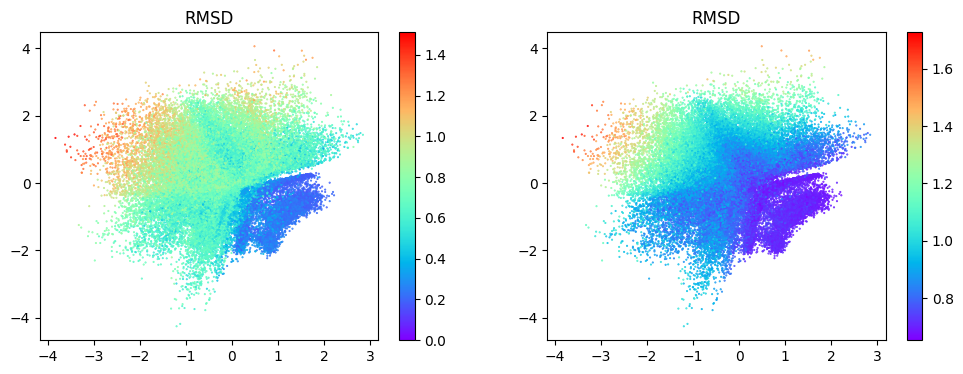

In [42]:
rg = md.compute_rg(tr_full)
base = md.load(conf)
rmsd = md.rmsd(tr_full,base[0])
cmap = plt.get_cmap('rainbow')
plt.figure(figsize=(12,4))
plt.subplot(121)
plt.scatter(lows[:,0],lows[:,1],marker='.',c=rmsd,cmap=cmap,s=1)
plt.colorbar(cmap=cmap)
plt.title("RMSD")
plt.subplot(122)
plt.scatter(lows[:,0],lows[:,1],marker='.',c=rg,cmap=cmap,s=1)
plt.colorbar(cmap=cmap)
plt.title("RMSD")
plt.savefig("rmsd-rg-norm.png")

## Torsions

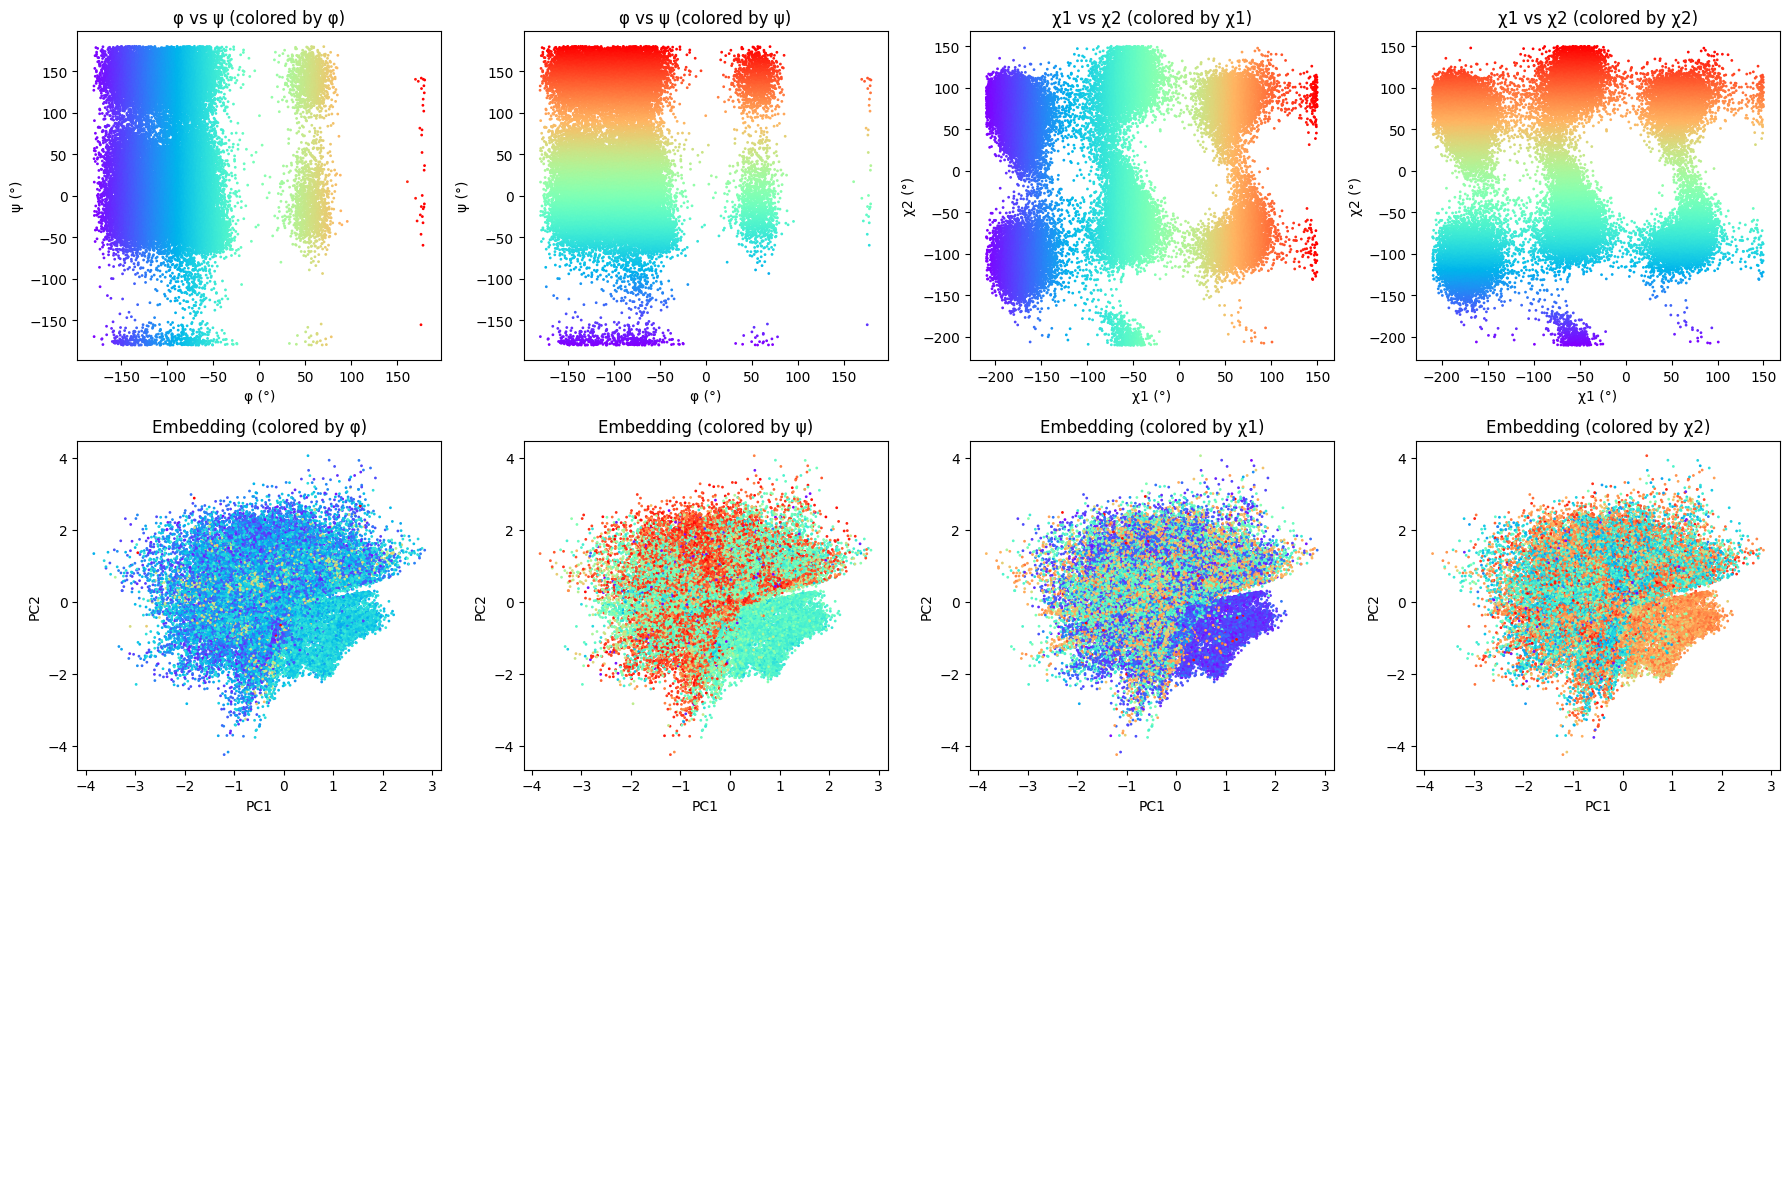

In [11]:
def wrap180_deg(a_rad):
    """Convert radians to degrees and wrap into [-180, 180)."""
    return (np.degrees(a_rad) + 180.0) % 360.0 - 180.0

# === INPUT ===
resid_pdb = 6   # residue number in the PDB
t = tr_full     # preloaded MDTraj trajectory
t.superpose(t[0], atom_indices=t.top.select("name CA"))

# === Find residue by PDB number ===
res = [r for r in t.top.residues if r.resSeq == resid_pdb][0]

# === Compute torsions ===
phi_idx, phi_rad = md.compute_phi(t)
psi_idx, psi_rad = md.compute_psi(t)
chi1_idx, chi1_rad = md.compute_chi1(t)
chi2_idx, chi2_rad = md.compute_chi2(t)

def get_col_for_res(torsion_idx, residue):
    """Return the torsion column corresponding to the given residue."""
    for i, atoms in enumerate(torsion_idx):
        resids = [t.top.atom(a).residue.index for a in atoms]
        if residue.index in resids:
            return i
    return None

i_phi  = get_col_for_res(phi_idx,  res)
i_psi  = get_col_for_res(psi_idx,  res)
i_chi1 = get_col_for_res(chi1_idx, res)
i_chi2 = get_col_for_res(chi2_idx, res)

phi  = wrap180_deg(phi_rad[:,  i_phi])  if i_phi  is not None else None
psi  = wrap180_deg(psi_rad[:,  i_psi])  if i_psi  is not None else None
chi1 = wrap180_deg(chi1_rad[:, i_chi1]) if i_chi1 is not None else None
chi2 = wrap180_deg(chi2_rad[:, i_chi2]) if i_chi2 is not None else None

    # Translate angles greater than 150 degrees to the negative range
chi1[chi1 > 150] -= 360
chi2[chi2 > 150] -= 360

# === Create figure grid ===
fig, axs = plt.subplots(3, 4, figsize=(18, 12))
plt.subplots_adjust(wspace=0.35, hspace=0.35)

# φ vs ψ (colored by φ)
axs[0, 0].scatter(phi, psi, s=1, c=phi, cmap="rainbow")
axs[0, 0].set_title("φ vs ψ (colored by φ)")
axs[0, 0].set_xlabel("φ (°)")
axs[0, 0].set_ylabel("ψ (°)")

# φ vs ψ (colored by ψ)
axs[0, 1].scatter(phi, psi, s=1, c=psi, cmap="rainbow")
axs[0, 1].set_title("φ vs ψ (colored by ψ)")
axs[0, 1].set_xlabel("φ (°)")
axs[0, 1].set_ylabel("ψ (°)")

# χ1 vs χ2 (colored by χ1)
axs[0, 2].scatter(chi1, chi2, s=1, c=chi1, cmap="rainbow")
axs[0, 2].set_title("χ1 vs χ2 (colored by χ1)")
axs[0, 2].set_xlabel("χ1 (°)")
axs[0, 2].set_ylabel("χ2 (°)")

# χ1 vs χ2 (colored by χ2)
axs[0, 3].scatter(chi1, chi2, s=1, c=chi2, cmap="rainbow")
axs[0, 3].set_title("χ1 vs χ2 (colored by χ2)")
axs[0, 3].set_xlabel("χ1 (°)")
axs[0, 3].set_ylabel("χ2 (°)")

# Embedding colored by φ
axs[1, 0].scatter(lows[:, 0], lows[:, 1], c=phi, cmap="rainbow", s=1)
axs[1, 0].set_title("Embedding (colored by φ)")
axs[1, 0].set_xlabel("PC1")
axs[1, 0].set_ylabel("PC2")

# Embedding colored by ψ
axs[1, 1].scatter(lows[:, 0], lows[:, 1], c=psi, cmap="rainbow", s=1)
axs[1, 1].set_title("Embedding (colored by ψ)")
axs[1, 1].set_xlabel("PC1")
axs[1, 1].set_ylabel("PC2")

# Embedding colored by χ1
axs[1, 2].scatter(lows[:, 0], lows[:, 1], c=chi1, cmap="rainbow", s=1)
axs[1, 2].set_title("Embedding (colored by χ1)")
axs[1, 2].set_xlabel("PC1")
axs[1, 2].set_ylabel("PC2")

# Embedding colored by χ2
axs[1, 3].scatter(lows[:, 0], lows[:, 1], c=chi2, cmap="rainbow", s=1)
axs[1, 3].set_title("Embedding (colored by χ2)")
axs[1, 3].set_xlabel("PC1")
axs[1, 3].set_ylabel("PC2")

# Leave last row empty for future plots or notes
for ax in axs[2, :]:
    ax.axis("off")

plt.tight_layout()
plt.savefig("torsions_norm.png")

## Alpha elics
* **Traj** must be the tranining .xtc and .pdb

Avarage alpha elics content: 0.160


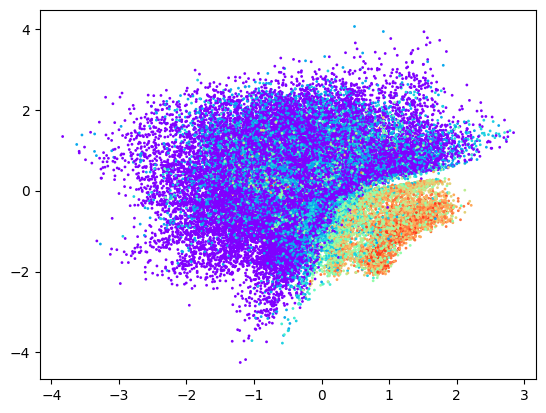

In [12]:
dssp = md.compute_dssp(tr_full, simplified=True) 
alpha_content_per_frame = np.mean(dssp == 'H', axis=1)
average_alpha_helix_content = np.mean(alpha_content_per_frame)

print(f"Avarage alpha elics content: {average_alpha_helix_content:.3f}")
plt.scatter(lows[:, 0], lows[:, 1], c=alpha_content_per_frame, cmap="rainbow", s=1)
plt.savefig("dssp_norm.png")

## Contact pairs
* **x**: residue number.
* **y**:  Ca, Cb or whatever belonging with X, the user wish to compute. 

In [13]:
for atom in tr_full.topology.atoms:
    print(atom.index, atom.name, atom.residue)

0 N ASP1
1 CA ASP1
2 CB ASP1
3 CG ASP1
4 OD1 ASP1
5 OD2 ASP1
6 C ASP1
7 O ASP1
8 N ALA2
9 CA ALA2
10 CB ALA2
11 C ALA2
12 O ALA2
13 N TYR3
14 CA TYR3
15 CB TYR3
16 CG TYR3
17 CD1 TYR3
18 CE1 TYR3
19 CZ TYR3
20 OH TYR3
21 CE2 TYR3
22 CD2 TYR3
23 C TYR3
24 O TYR3
25 N ALA4
26 CA ALA4
27 CB ALA4
28 C ALA4
29 O ALA4
30 N GLN5
31 CA GLN5
32 CB GLN5
33 CG GLN5
34 CD GLN5
35 OE1 GLN5
36 NE2 GLN5
37 C GLN5
38 O GLN5
39 N TRP6
40 CA TRP6
41 CB TRP6
42 CG TRP6
43 CD1 TRP6
44 NE1 TRP6
45 CE2 TRP6
46 CZ2 TRP6
47 CH2 TRP6
48 CZ3 TRP6
49 CE3 TRP6
50 CD2 TRP6
51 C TRP6
52 O TRP6
53 N LEU7
54 CA LEU7
55 CB LEU7
56 CG LEU7
57 CD1 LEU7
58 CD2 LEU7
59 C LEU7
60 O LEU7
61 N ALA8
62 CA ALA8
63 CB ALA8
64 C ALA8
65 O ALA8
66 N ASP9
67 CA ASP9
68 CB ASP9
69 CG ASP9
70 OD1 ASP9
71 OD2 ASP9
72 C ASP9
73 O ASP9
74 N GLY10
75 CA GLY10
76 C GLY10
77 O GLY10
78 N GLY11
79 CA GLY11
80 C GLY11
81 O GLY11
82 N PRO12
83 CD PRO12
84 CG PRO12
85 CB PRO12
86 CA PRO12
87 C PRO12
88 O PRO12
89 N SER13
90 CA SER13
91 CB SER

In [14]:
res1 = 2
name1 = "N"
res2 = 19
name2 = "N"

atom_indices = (tr_full.topology.select(f'"resid {res1} and name {name1}"')[0],  
                tr_full.topology.select(f'"resid {res2} and name {name1}"')[0])

distances = md.compute_distances(tr_full, [atom_indices]) 
plt.scatter(lows[:, 0], lows[:, 1], c=distances, cmap="rainbow", s=1)
plt.savefig(f'"distances_norm_{res1}-{name1}_{res2}-{name2}.png"')

ValueError: Cannot use a single literal as a boolean. Choked on node with value resid 2 and name N

## Angles
* **x**: same as above.
* **y**:  same as above

In [ ]:
atom_indices = tr_full.topology.select("resid 2 and name N")[0], \
               tr_full.topology.select("resid 12 and name C")[0], \
               tr_full.topology.select("resid 19 and name O")[0]

# Radiants
angles = md.compute_angles(tr_full, [atom_indices])  

# Degree
angles_deg = np.rad2deg(angles[:, 0])
plt.scatter(lows[:, 0], lows[:, 1], c=angles_deg, cmap="rainbow", s=1)

## plane
* **x**: same as above.
* **y**:  same as above

In [ ]:
atom1 = tr_full.topology.select("resid 2 and name N")[0]
atom2 = tr_full.topology.select("resid 8 and name C")[0]
atom3 = tr_full.topology.select("resid 13 and name C")[0]
atom4 = tr_full.topology.select("resid 19 and name O")[0]

# Radiants
dihedrals = md.compute_dihedrals(tr_full, [[atom1, atom2, atom3, atom4]])
# Degree
dihedrals_deg = np.rad2deg(dihedrals[:, 0])  
plt.scatter(lows[:, 0], lows[:, 1], c=dihedrals_deg, cmap="rainbow", s=1)

## Save all pictures

In [ ]:
os.makedirs("0x.picture", exist_ok=True)

for file in glob.glob("*.png"):
        shutil.move(file, os.path.join("03.pictures", file))